In [1]:
import sc2ts
import pandas
import numpy as np
import tszip
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
ts = tszip.load("data/sc2ts_viridian_v1.trees.tsz")
ts

In [3]:
ds = sc2ts.Dataset("data/viridian_mafft_2024-10-14_v1.vcz.zip")
ds

Dataset at data/viridian_mafft_2024-10-14_v1.vcz.zip with 4484157 samples, 29903 variants, and 30 metadata fields. See ds.metadata.field_descriptors() for a description of the fields.

In [4]:
df_node = sc2ts.node_data(ts).set_index("node_id")
df_node

,pango,sample_id,scorpio,is_sample,is_recombinant,num_mutations,max_descendant_samples,date
node_id,,,,,,,,
0,B,Vestigial_ignore,.,False,False,0,0,2019-11-17
1,B,Wuhan/Hu-1/2019,.,False,False,0,2482157,2019-12-26
2,A,SRR11772659,.,True,False,1,255,2020-01-19
3,B,SRR11397727,.,True,False,0,1,2020-01-24
4,B,SRR11397730,.,True,False,0,1,2020-01-24
...,...,...,...,...,...,...,...,...
2689049,AY.103,,Delta (B.1.617.2-like),False,False,1,3,2021-11-11
2689050,BA.2.9,,Omicron (BA.2-like),False,False,3,2,2022-03-04
2689051,AY.4,,Delta (AY.4-like),False,False,1,3,2021-09-01


In [5]:
df_recombinants = pd.read_csv("data/recombinants.csv").set_index("recombinant")
df_recombinants

,sample_id,num_descendant_samples,num_samples,distinct_sample_pango,interval_left,interval_right,num_mutations,Viridian_amplicon_scheme,Artic_primer_version,date_added,...,parent_mrca_scorpio,parent_mrca_time,parent_mrca_date,is_rebar_recombinant,num_mutations_k1000,num_mutations_k4,parent_pangonet_distance,net_min_supporting_loci_lft,net_min_supporting_loci_rgt,net_min_supporting_loci_lft_rgt_ge_4
recombinant,,,,,,,,,,,,,,,,,,,,,
1530,ERR4437465,1,1,1,8783,13617,2,COVID-ARTIC-V3,3,2020-03-22,...,.,1153.000000,2019-12-26,True,7,2,2,5,5,True
22500,ERR4638271,1,1,1,26528,26714,2,COVID-ARTIC-V3,3,2020-07-23,...,.,1120.002530,2020-01-28,True,6,2,2,11,2,False
26465,ERR4615866,54,1,1,15325,21855,1,COVID-ARTIC-V3,3,2020-08-24,...,.,1120.205275,2020-01-28,True,6,1,2,4,10,True
27003,ERR4671078,3,1,1,22993,25563,2,COVID-ARTIC-V3,3,2020-08-26,...,.,1120.205275,2020-01-28,True,14,2,3,14,10,True
28379,SRR21719160,3,1,1,6542,9515,0,COVID-ARTIC-V3,.,2020-09-02,...,.,1120.205275,2020-01-28,False,4,0,2,5,19,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1430261,ERR10839848,1,1,1,19327,20741,2,COVID-ARTIC-V4.1,4.1alt,2023-01-23,...,Omicron (BA.2-like),452.000000,2021-11-26,True,16,2,11,18,23,True
1430452,SRR23358540,1,1,1,9867,12160,1,COVID-ARTIC-V4.1,.,2023-01-23,...,Omicron (BA.2-like),452.000000,2021-11-26,True,12,1,16,13,30,True
1431988,ERR10931828,1,1,1,19887,21811,2,COVID-ARTIC-V4.1,4.1alt,2023-01-29,...,Omicron (BA.2-like),221.917393,2022-07-15,True,6,2,1,5,4,True


In [6]:
df_pango_x = pd.read_csv("data/bigtable_sc2ts.csv")
df_pango_x

,pango,github_issue,is_in_results,is_in_arg,is_in_matches,is_clean,is_nested,re_node,type,parent_left_pango,parent_right_pango,parents_extra,interval_left,interval_right,intervals_extra
0,XA,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,False,122444.0,simple,B.1.177.18,B.1.1.7,NaN,20411,21767,NaN
1,XAA,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,1058654.0,simple,BA.1.1.15,BA.2.9,NaN,4322,5386,NaN
2,XAC,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,964555.0,simple,BA.2,BA.1.17.2,NaN,24504,26060,NaN
3,XAD,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,964555.0,simple,BA.2,BA.1.17.2,NaN,24504,26060,NaN
4,XAE,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,964555.0,simple,BA.2,BA.1.17.2,NaN,24504,26060,NaN
5,XAF,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,False,False,1177107.0,simple,BA.1.1,BA.2,NaN,10199,10447,NaN
6,XAG,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,1058654.0,simple,BA.1.1.15,BA.2.9,NaN,4322,5386,NaN
7,XAJ,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,False,NaN,-1.0,non,NaN,NaN,NaN,NaN,NaN,NaN
8,XAL,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,1003220.0,simple,BA.1.1,BA.2,NaN,17411,21633,NaN
9,XAM,https://github.com/jeromekelleher/sc2ts-paper/...,True,True,NaN,True,True,1058654.0,simple,BA.1.1.15,BA.2.9,NaN,4322,5386,NaN


In [7]:
non_recombs = df_pango_x[df_pango_x["type"] == "non"].pango.values
non_recombs

array(['XAJ', 'XAN', 'XAS', 'XAU', 'XAV', 'XAZ', 'XB', 'XBE', 'XBK',
       'XBQ', 'XN', 'XP', 'XAB', 'XAH', 'XBL', 'XBZ', 'XCG'], dtype=object)

In [8]:
data = []
for pango in non_recombs:
    df_pango = df_node[(df_node.pango == pango)].sort_values("date")
    num_samples = np.sum(df_pango.is_sample)
    
    if num_samples > 0:
        first = df_pango.iloc[0]
        data.append({
            "pango": pango,
            "num_arg_samples": num_samples,
            "descendant_samples": first.max_descendant_samples,
            "num_mutations": first.num_mutations,
            "node": first.index,
            "plausibility_score": first.num_mutations 
        })
    else:
        print("skipping", pango)
    
df_non_recombs = pd.DataFrame(data)
df_non_recombs

skipping XAB
skipping XAH
skipping XBL
skipping XBZ
skipping XCG


,pango,num_arg_samples,descendant_samples,num_mutations,node,plausibility_score
0,XAJ,18,18,11,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",11
1,XAN,7,7,5,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",5
2,XAS,77,77,1,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",1
3,XAU,8,8,1,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",1
4,XAV,13,13,3,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",3
5,XAZ,133,131,1,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",1
6,XB,192,21,1,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",1
7,XBE,65,65,3,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",3
8,XBK,6,7,1,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",1
9,XBQ,14,14,1,"Index(['pango', 'sample_id', 'scorpio', 'is_sa...",1


In [9]:
re_nodes = df_pango_x[~df_pango_x.re_node.isna()].re_node.astype(int).values
re_nodes

array([ 122444, 1058654,  964555,  964555,  964555, 1177107, 1058654,
            -1, 1003220, 1058654,      -1,  964555,      -1,      -1,
            -1,      -1,      -1, 1396207, 1378208,      -1, 1420385,
       1291970, 1379419,      -1, 1348822,      -1, 1420166,  414488,
        965353,  946761, 1083412,  965353,  966905, 1034619, 1003220,
            -1,      -1, 1058654, 1058654, 1000242, 1058654, 1159411,
       1187989,  964555])

In [10]:
re_nodes = np.unique(re_nodes)
assert re_nodes[0] == -1
re_nodes = re_nodes[1:]
re_nodes

array([ 122444,  414488,  946761,  964555,  965353,  966905, 1000242,
       1003220, 1034619, 1058654, 1083412, 1159411, 1177107, 1187989,
       1291970, 1348822, 1378208, 1379419, 1396207, 1420166, 1420385])

In [11]:
data = []
for re_node in re_nodes:
    node_data = df_node.loc[re_node]
    re_data = df_recombinants.loc[re_node]
    pangos = df_pango_x[df_pango_x.re_node == re_node].pango.values
    data.append({
        "node": re_node,
        "node_pango": node_data.pango,
        "pangos": pangos,
        "recombinant": True,
        "plausibility": re_data.num_mutations_k1000 - re_data.num_mutations_k4,
        
    })
    

for pango in non_recombs:
    df_pango = df_node[(df_node.pango == pango)].sort_values("date")
    num_samples = np.sum(df_pango.is_sample)
    
    if num_samples > 0:
        first = df_pango.iloc[0]
    
        data.append({
            "node": first.name,
            "node_pango": pango,
            "pangos": [pango],
          
            "recombinant": False,
            "plausibility": first.num_mutations 
        })
    else:
        print("skipping", pango)

pango_events = pd.DataFrame(data).set_index("node")
pango_events 

skipping XAB
skipping XAH
skipping XBL
skipping XBZ
skipping XCG


,node_pango,pangos,recombinant,plausibility
node,,,,
122444,XA,[XA],True,12
414488,XC,[XC],True,14
946761,XF,[XF],True,5
964555,BA.2,"[XAC, XAD, XAE, XAP, XZ]",True,6
965353,BA.2,"[XE, XH]",True,6
966905,BA.2,[XJ],True,5
1000242,XS,[XS],True,11
1003220,XM,"[XAL, XM]",True,6
1034619,XL,[XL],True,8


In [12]:
pango_events["date"] = df_node.loc[pango_events.index].date
pango_events["descendant_samples"] = df_node.loc[pango_events.index].max_descendant_samples

In [13]:
pango_events

,node_pango,pangos,recombinant,plausibility,date,descendant_samples
node,,,,,,
122444,XA,[XA],True,12,2021-01-13,39
414488,XC,[XC],True,14,2021-07-12,5
946761,XF,[XF],True,5,2022-01-10,16
964555,BA.2,"[XAC, XAD, XAE, XAP, XZ]",True,6,2022-01-16,252
965353,BA.2,"[XE, XH]",True,6,2021-12-31,1156
966905,BA.2,[XJ],True,5,2022-01-14,85
1000242,XS,[XS],True,11,2022-01-27,17
1003220,XM,"[XAL, XM]",True,6,2022-01-28,45
1034619,XL,[XL],True,8,2022-01-15,64


In [23]:
pango_events.shape

(33, 6)

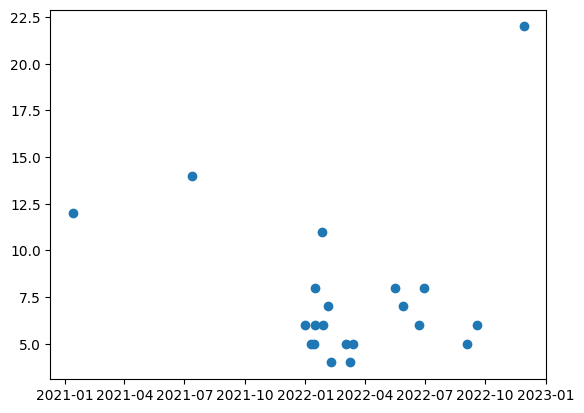

In [14]:
plt.scatter(pango_events[pango_events.recombinant].date, pango_events[pango_events.recombinant].plausibility)

In [21]:
import seaborn as sns

pango_recombs = pango_events[pango_events.recombinant]
pango_recombs

,node_pango,pangos,recombinant,plausibility,date,descendant_samples
node,,,,,,
122444,XA,[XA],True,12,2021-01-13,39
414488,XC,[XC],True,14,2021-07-12,5
946761,XF,[XF],True,5,2022-01-10,16
964555,BA.2,"[XAC, XAD, XAE, XAP, XZ]",True,6,2022-01-16,252
965353,BA.2,"[XE, XH]",True,6,2021-12-31,1156
966905,BA.2,[XJ],True,5,2022-01-14,85
1000242,XS,[XS],True,11,2022-01-27,17
1003220,XM,"[XAL, XM]",True,6,2022-01-28,45
1034619,XL,[XL],True,8,2022-01-15,64


In [24]:
pango_non_recombs = pango_events[~pango_events.recombinant]
pango_non_recombs

,node_pango,pangos,recombinant,plausibility,date,descendant_samples
node,,,,,,
1276376,XAJ,[XAJ],False,11,2022-05-29,18
1301399,XAN,[XAN],False,5,2022-06-23,7
1265115,XAS,[XAS],False,1,2022-06-10,77
1231548,XAU,[XAU],False,1,2022-05-06,8
1269391,XAV,[XAV],False,3,2022-06-15,13
1246944,XAZ,[XAZ],False,1,2022-04-27,131
232089,XB,[XB],False,1,2021-01-13,21
1363926,XBE,[XBE],False,3,2022-07-09,65
1425824,XBK,[XBK],False,1,2022-08-09,7


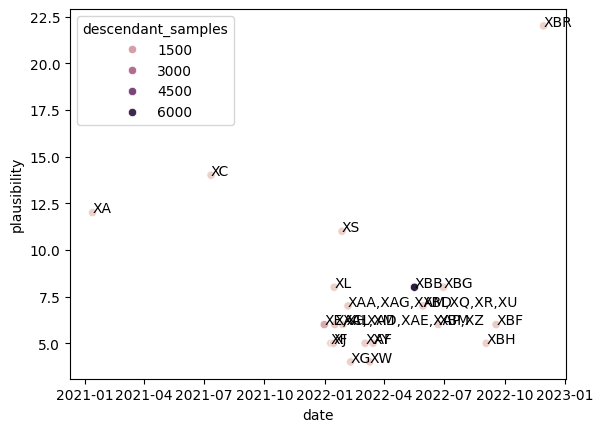

In [17]:
p1 = sns.scatterplot(x="date", y="plausibility", hue="descendant_samples", data=pango_recombs);

data= pango_recombs
x = "date"
y = "plausibility"
for line, data in pango_recombs.iterrows():
    p1.text(data[x], data[y], 
        ",".join(data["pangos"]), horizontalalignment='left', 
        size='medium', color='black')


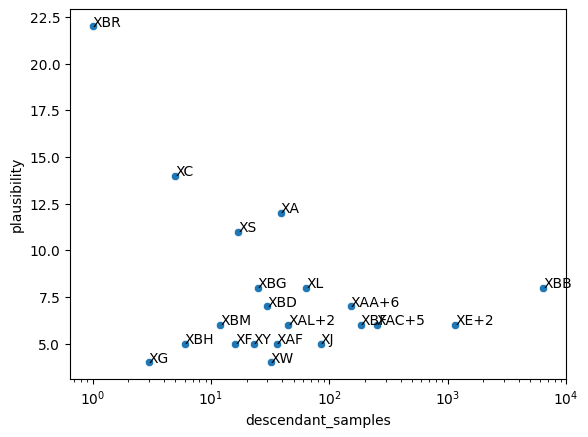

In [18]:
x = "descendant_samples"
y = "plausibility"
p1 = sns.scatterplot(x=x, y=y, data=pango_recombs);
plt.xscale('log')
for line, data in pango_recombs.iterrows():
    label = data["pangos"][0]
    if len( data["pangos"]) > 1:
        label += f"+{len(data['pangos'])}"
    p1.text(data[x], data[y], label, horizontalalignment='left', 
        size='medium', color='black')

In [19]:
pango_recombs

,node_pango,pangos,recombinant,plausibility,date,descendant_samples,log_descendant_samples
node,,,,,,,
122444,XA,[XA],True,12,2021-01-13,39,1.591065
414488,XC,[XC],True,14,2021-07-12,5,0.698970
946761,XF,[XF],True,5,2022-01-10,16,1.204120
964555,BA.2,"[XAC, XAD, XAE, XAP, XZ]",True,6,2022-01-16,252,2.401401
965353,BA.2,"[XE, XH]",True,6,2021-12-31,1156,3.062958
966905,BA.2,[XJ],True,5,2022-01-14,85,1.929419
1000242,XS,[XS],True,11,2022-01-27,17,1.230449
1003220,XM,"[XAL, XM]",True,6,2022-01-28,45,1.653213
1034619,XL,[XL],True,8,2022-01-15,64,1.806180


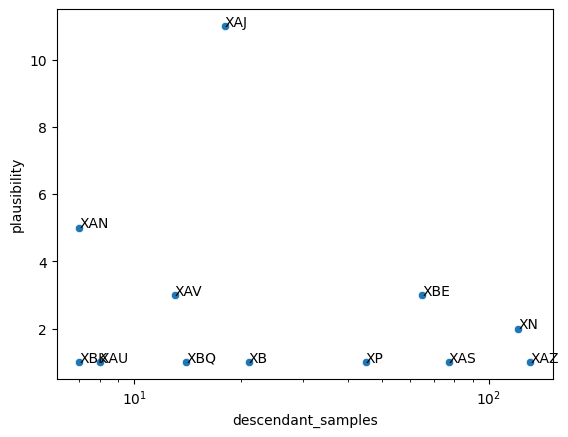

In [26]:
x = "descendant_samples"
y = "plausibility"
p1 = sns.scatterplot(x=x, y=y, data=pango_non_recombs);
plt.xscale('log')
for line, data in pango_non_recombs.iterrows():
    label = data["pangos"][0]
    if len( data["pangos"]) > 1:
        label += f"+{len(data['pangos'])}"
    p1.text(data[x], data[y], label, horizontalalignment='left', 
        size='medium', color='black')